In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)

op="diff"

current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if (file.endswith(".csv")) and (op in file):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s


/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_diff_fp32.csv
   operator dtype      size  time_us  mem_bytes
0      diff  fp32     81920    71.88     573440
1      diff  fp32   2703360   103.71   18923520
2      diff  fp32   5324800   154.65   37273600
3      diff  fp32   7946240   205.90   55623680
4      diff  fp32  10567680   258.00   73973760
5      diff  fp32  13189120   304.50   92323840
6      diff  fp32  15810560   342.43  110673920
7      diff  fp32  18432000   380.42  129024000
8      diff  fp32  21053440   418.44  147374080
9      diff  fp32  23674880   456.64  165724160
10     diff  fp32  26296320   495.71  184074240
11     diff  fp32  28917760   530.67  202424320
12     diff  fp32  31539200   569.97  220774400
13     diff  fp32  34160640   606.21  239124480
14     diff  fp32  36782080   644.78  257474560
15     

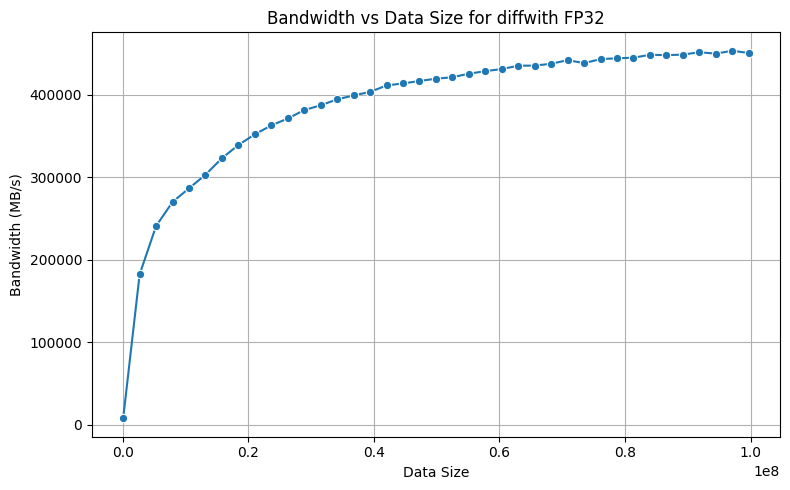

In [5]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', data=tot_dataframe, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
dtype = tot_dataframe['dtype'].tolist()
title = 'Bandwidth vs Data Size for ' + str(op) + ' with ' +  dtype[0]
plt.title(title)
plt.tight_layout()

plt.grid(True)
filename = op + ".pdf"
plt.savefig(filename)
plt.show()
